In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

In [ ]:
# Magic command must be outside the class to avoid Colab errors
%matplotlib inline

In [ ]:
class ChurnDataPipeline:
    """
    Integrated pipeline to handle Level 1 (Google Colab Version):
    Task 1 (Data Cleaning) -> Task 2 (EDA)
    """

    def __init__(self, filepath: str):
        # Load raw data
        try:
            self.raw_df = pd.read_csv(filepath)
            self.clean_df = None
            print(f"[OK] Dataset '{filepath}' loaded successfully.")
        except FileNotFoundError:
            print(f"[Error] File '{filepath}' not found. Please ensure it is uploaded to the 'Files' directory on the left panel.")

        # UI/UX configuration for plots
        sns.set_theme(style="whitegrid")
        self.colors = ["#2ecc71", "#e74c3c"] # Green for Retained, Red for Churn

    # ==========================================
    # PHASE 1: DATA CLEANING & PREPROCESSING
    # ==========================================
    def task1_clean_data(self):
        """Executes data cleaning: handling missing values and duplicates."""
        print("\n" + "="*30)
        print("=== TASK 1: DATA CLEANING ===")
        print("="*30)
        df = self.raw_df.copy()

        # 1. Missing Values Check
        missing = df.isnull().sum().sum()
        print(f"[*] Total Missing Values found: {missing}")
        if missing > 0:
            df = df.dropna()
            print("    -> Missing values successfully handled.")

        # 2. Duplicates Check & Removal
        duplicates = df.duplicated().sum()
        print(f"[*] Total Duplicate Rows found: {duplicates}")
        if duplicates > 0:
            df = df.drop_duplicates()
            print("    -> Duplicate rows successfully removed.")

        self.clean_df = df
        print("[V] Data Cleaning Complete. Data is ready for analysis.")

    # ==========================================
    # PHASE 2: EXPLORATORY DATA ANALYSIS (EDA)
    # ==========================================
    def task2_eda_summary(self):
        """Displays descriptive statistics of the cleaned data."""
        print("\n" + "="*35)
        print("=== TASK 2: EDA - SUMMARY STATS ===")
        print("="*35)
        if self.clean_df is None: self.task1_clean_data()

        cols_to_show = ['Total day minutes', 'Total day charge', 'Customer service calls']
        stats = self.clean_df[cols_to_show].describe().T
        display(stats[['mean', '50%', 'min', 'max', 'std']])

    def task2_eda_visualizations(self):
        """Creates distribution and correlation visualizations."""
        if self.clean_df is None: self.task1_clean_data()

        fig = plt.figure(figsize=(16, 10))

        # Plot 1: Histogram
        ax1 = plt.subplot(2, 2, 1)
        sns.histplot(self.clean_df['Total day minutes'], kde=True, color='#3498db', ax=ax1)
        ax1.set_title('Distribution of Total Day Minutes', fontweight='bold')
        ax1.set_ylabel('Frequency')

        # Plot 2: Boxplot
        ax2 = plt.subplot(2, 2, 2)
        sns.boxplot(data=self.clean_df, x='Churn', y='Customer service calls', palette=self.colors, ax=ax2)
        ax2.set_title('Customer Service Calls vs Churn', fontweight='bold')

        # Plot 3: Heatmap
        ax3 = plt.subplot(2, 2, (3, 4))
        numeric_df = self.clean_df.select_dtypes(include=[np.number])
        corr = numeric_df.corr()
        mask = np.triu(np.ones_like(corr, dtype=bool))
        sns.heatmap(corr, mask=mask, cmap='coolwarm', annot=False, ax=ax3, linewidths=0.5)
        ax3.set_title('Correlation Heatmap of Numerical Features', fontweight='bold')

        plt.tight_layout()
        plt.show()

In [ ]:
# Initialize and execute pipeline
pipeline = ChurnDataPipeline('churn-bigml-80.csv')

[OK] Dataset 'churn-bigml-80.csv' loaded successfully.


In [ ]:
# Execute Task 1
pipeline.task1_clean_data()


=== TASK 1: DATA CLEANING ===
[*] Total Missing Values found: 0
[*] Total Duplicate Rows found: 0
[V] Data Cleaning Complete. Data is ready for analysis.



=== TASK 2: EDA - SUMMARY STATS ===


,mean,50%,min,max,std
Total day minutes,179.481620,179.95,0.0,350.80,54.210350
Total day charge,30.512404,30.59,0.0,59.64,9.215733
Customer service calls,1.562641,1.00,0.0,9.00,1.311236


/tmp/ipykernel_4139/3442602161.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=self.clean_df, x='Churn', y='Customer service calls', palette=self.colors, ax=ax2)


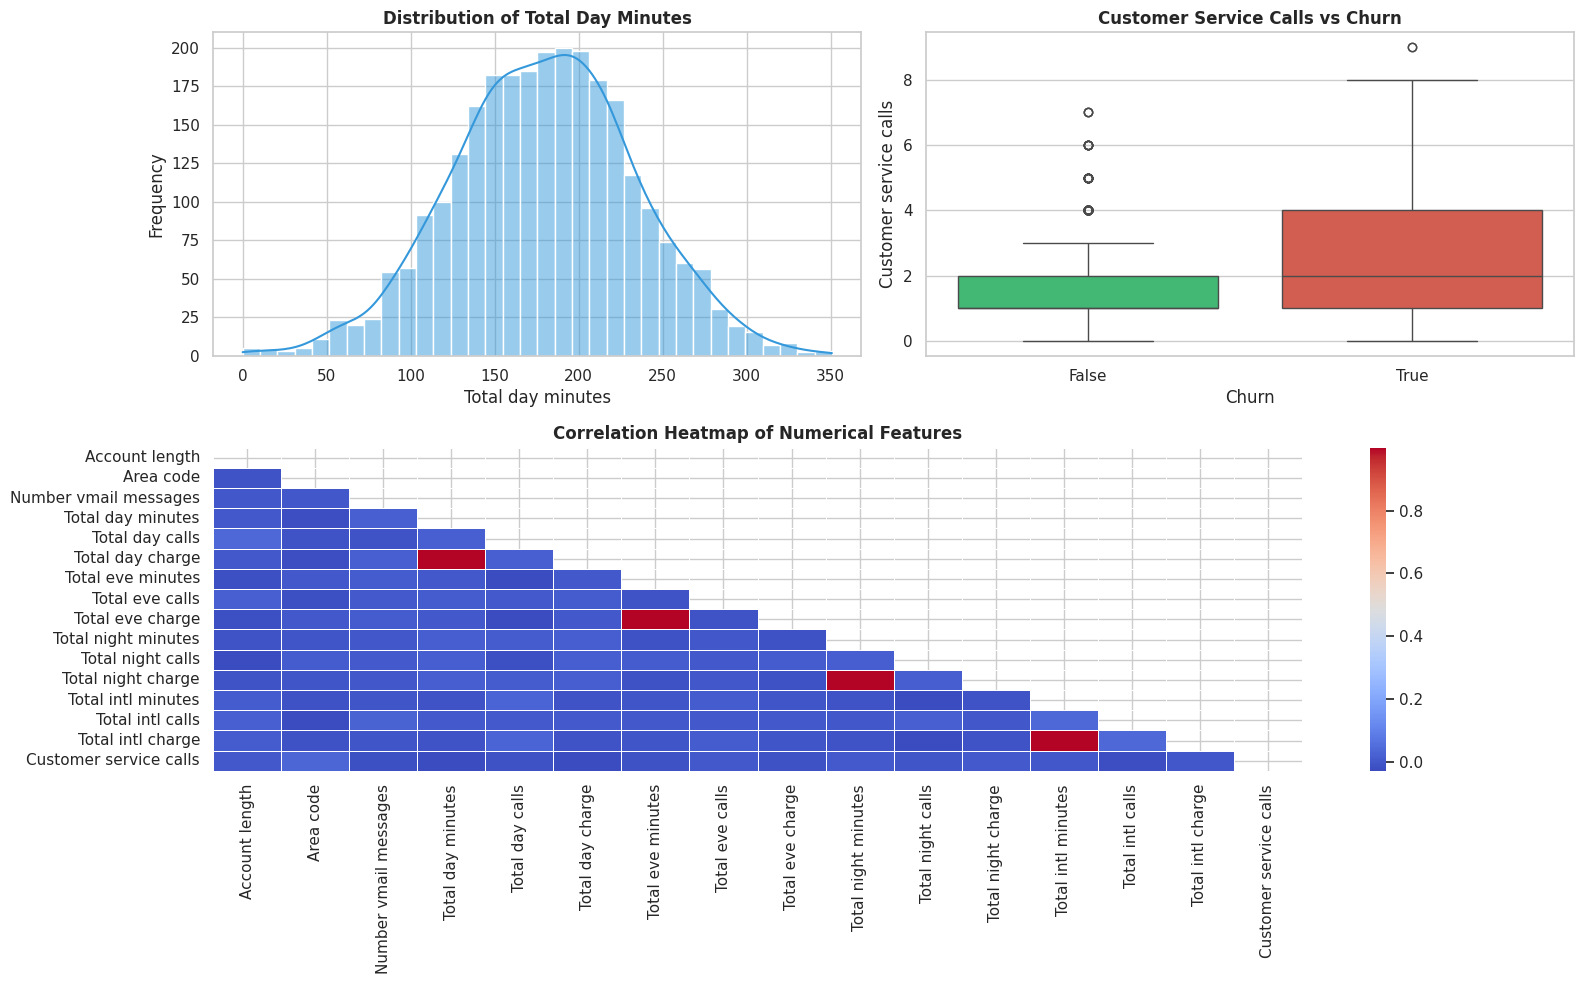

In [ ]:
  # Execute Task 2
pipeline.task2_eda_summary()
pipeline.task2_eda_visualizations()